In [3]:
%pip install openpyxl


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

### Imports

In [1]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    from catboost import CatBoostRegressor
    from lightgbm import LGBMRegressor
except ImportError:
    XGBRegressor = CatBoostRegressor = LGBMRegressor = None
    print('xgboost / catboost / lightgbm not installed: those 3 models will be skipped.')

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

xgboost / catboost / lightgbm not installed: those 3 models will be skipped.


In [ ]:
file_path = 'flexural_strength.xlsx'  

try:
    sheet1_data = pd.read_excel(file_path, sheet_name='Sheet1')
except FileNotFoundError:
    raise FileNotFoundError(f"'{file_path}' not found. Put it in the same folder as this notebook.")

# Some headers have trailing spaces (e.g. 'fibercontent ', 'fiberLength ')
sheet1_data.columns = sheet1_data.columns.str.strip()

print('Shape:', sheet1_data.shape)
print('Missing values:', sheet1_data.isna().sum().sum())
print('Duplicate rows:', sheet1_data.duplicated().sum())

x = sheet1_data.drop(columns=['flexuralstrength'])
y = sheet1_data['flexuralstrength']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_STATE)

Shape: (278, 13)
Missing values: 0
Duplicate rows: 3


In [5]:
def scaled(estimator):
    """Standardize features before scale-sensitive models."""
    return Pipeline([('scaler', StandardScaler()), ('model', estimator)])

regressors = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": scaled(Ridge()),
    "Lasso Regression": scaled(Lasso()),
    "ElasticNet Regression": scaled(ElasticNet()),
    "Huber Regression": scaled(HuberRegressor(max_iter=1000)),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostRegressor(random_state=RANDOM_STATE),
    "Support Vector Regression": scaled(SVR()),
    "K-Nearest Neighbors": scaled(KNeighborsRegressor()),
    "MLP Regressor": scaled(MLPRegressor(max_iter=2000, random_state=RANDOM_STATE)),
    "Gaussian Process": scaled(GaussianProcessRegressor(normalize_y=True, random_state=RANDOM_STATE)),
    "Polynomial Regression (Degree 2)": make_pipeline(StandardScaler(), PolynomialFeatures(2), LinearRegression()),
    "Polynomial Regression (Degree 3)": make_pipeline(StandardScaler(), PolynomialFeatures(3), LinearRegression()),
}

# Boosting libraries are added only if installed
if XGBRegressor is not None:
    regressors["XGBoost"] = XGBRegressor(random_state=RANDOM_STATE)
    regressors["CatBoost"] = CatBoostRegressor(verbose=0, random_state=RANDOM_STATE)
    regressors["LightGBM"] = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)

# Hyperparameter grids (the 'model__' prefix is added automatically for scaled models)
param_grids = {
    "Ridge Regression": {"alpha": [0.1, 1.0, 10.0]},
    "Lasso Regression": {"alpha": [0.01, 0.1, 1.0]},
    "ElasticNet Regression": {"alpha": [0.01, 0.1, 1.0], "l1_ratio": [0.1, 0.5, 0.9]},
    "Decision Tree": {"max_depth": [3, 5, 10]},
    "Random Forest": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]},
    "Extra Trees": {"n_estimators": [50, 100, 200], "max_depth": [None, 10, 20]},
    "Gradient Boosting": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]},
    "AdaBoost": {"n_estimators": [50, 100, 200]},
    "XGBoost": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]},
    "LightGBM": {"n_estimators": [50, 100, 200], "learning_rate": [0.01, 0.1, 0.2]},
    "Support Vector Regression": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]},
    "K-Nearest Neighbors": {"n_neighbors": [3, 5, 10]},
    "MLP Regressor": {"hidden_layer_sizes": [(50,), (100,), (50, 50)], "alpha": [0.0001, 0.001, 0.01]},
    "Gaussian Process": {"alpha": [1e-10, 1e-5, 1e-2]},
}

results = []
predictions = {}

for name, model in regressors.items():
    if name in param_grids:
        grid = param_grids[name]
        if isinstance(model, Pipeline) and 'model' in model.named_steps:
            grid = {f'model__{k}': v for k, v in grid.items()}
        search = GridSearchCV(model, grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
        search.fit(x_train, y_train)
        best_model = search.best_estimator_
        print(f"Best parameters for {name}: {search.best_params_}")
    else:
        best_model = model.fit(x_train, y_train)

    # Compute metrics FIRST, then store them (this was the off-by-one bug)
    y_pred = best_model.predict(x_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} MSE: {mse:.3f}, R2: {r2:.4f}\n")

    results.append({'Model': name, 'Mean Square Error': mse, 'R2 Score': r2})
    predictions[name] = y_pred

Linear Regression MSE: 4.223, R2: 0.3968

Best parameters for Ridge Regression: {'model__alpha': 10.0}
Ridge Regression MSE: 4.350, R2: 0.3788

Best parameters for Lasso Regression: {'model__alpha': 0.01}
Lasso Regression MSE: 4.288, R2: 0.3875

Best parameters for ElasticNet Regression: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
ElasticNet Regression MSE: 4.257, R2: 0.3921

Huber Regression MSE: 4.632, R2: 0.3385

Best parameters for Decision Tree: {'max_depth': 10}
Decision Tree MSE: 1.189, R2: 0.8302

Best parameters for Random Forest: {'max_depth': 10, 'n_estimators': 100}
Random Forest MSE: 0.857, R2: 0.8776

Best parameters for Extra Trees: {'max_depth': 20, 'n_estimators': 100}
Extra Trees MSE: 0.583, R2: 0.9168

Best parameters for Gradient Boosting: {'learning_rate': 0.1, 'n_estimators': 200}
Gradient Boosting MSE: 0.584, R2: 0.9165

Best parameters for AdaBoost: {'n_estimators': 200}
AdaBoost MSE: 1.467, R2: 0.7904

Best parameters for Support Vector Regression: {'model__

In [6]:
results_df = (pd.DataFrame(results)
              .sort_values('R2 Score', ascending=False)
              .reset_index(drop=True))
display(results_df.round(4))

,Model,Mean Square Error,R2 Score
0,Extra Trees,0.5828,0.9168
1,Gradient Boosting,0.5843,0.9165
2,Gaussian Process,0.8198,0.8829
3,Random Forest,0.8572,0.8776
4,Decision Tree,1.1888,0.8302
5,MLP Regressor,1.2124,0.8268
6,AdaBoost,1.4674,0.7904
7,K-Nearest Neighbors,1.5401,0.7800
8,Support Vector Regression,1.7650,0.7479
9,Polynomial Regression (Degree 2),1.9549,0.7208


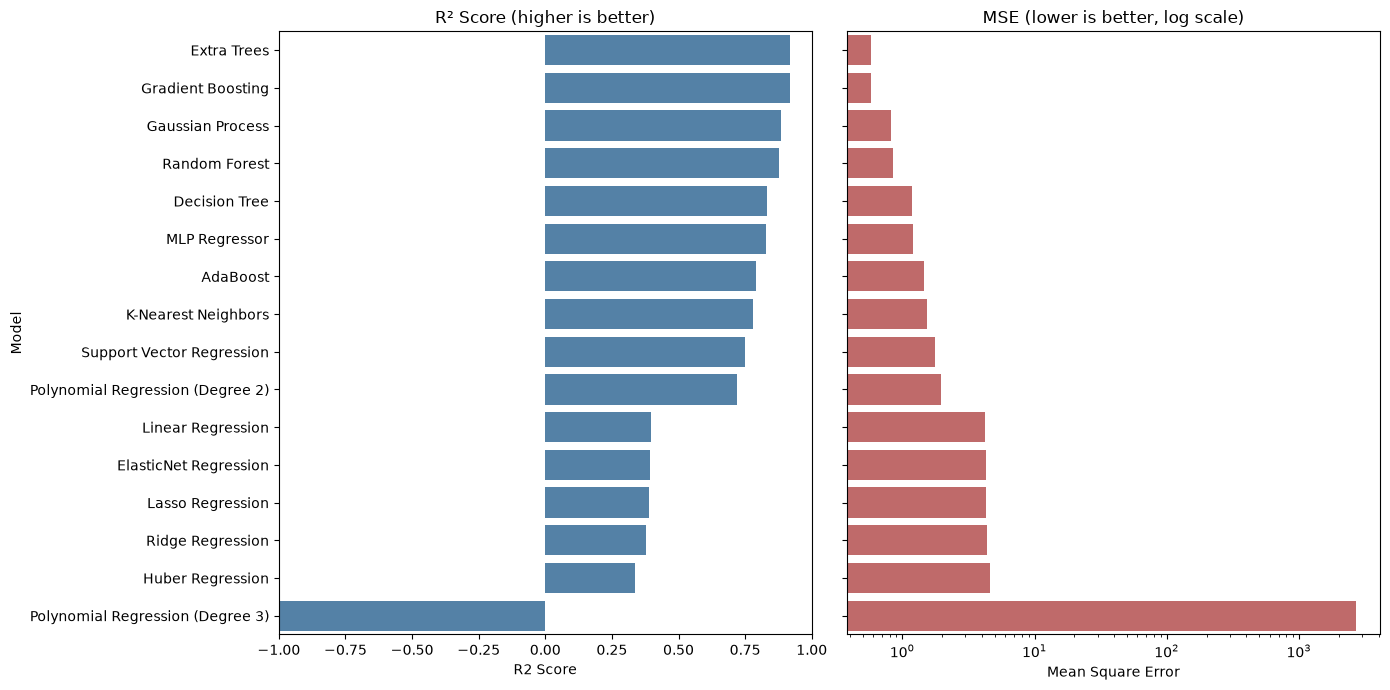

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
order = results_df['Model']

sns.barplot(y='Model', x='R2 Score', data=results_df, order=order, ax=axes[0], color='steelblue')
axes[0].set_title('R² Score (higher is better)')
axes[0].set_xlim(-1, 1)          # keeps a badly overfit model from squashing the chart

sns.barplot(y='Model', x='Mean Square Error', data=results_df, order=order, ax=axes[1], color='indianred')
axes[1].set_title('MSE (lower is better, log scale)')
axes[1].set_xscale('log')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

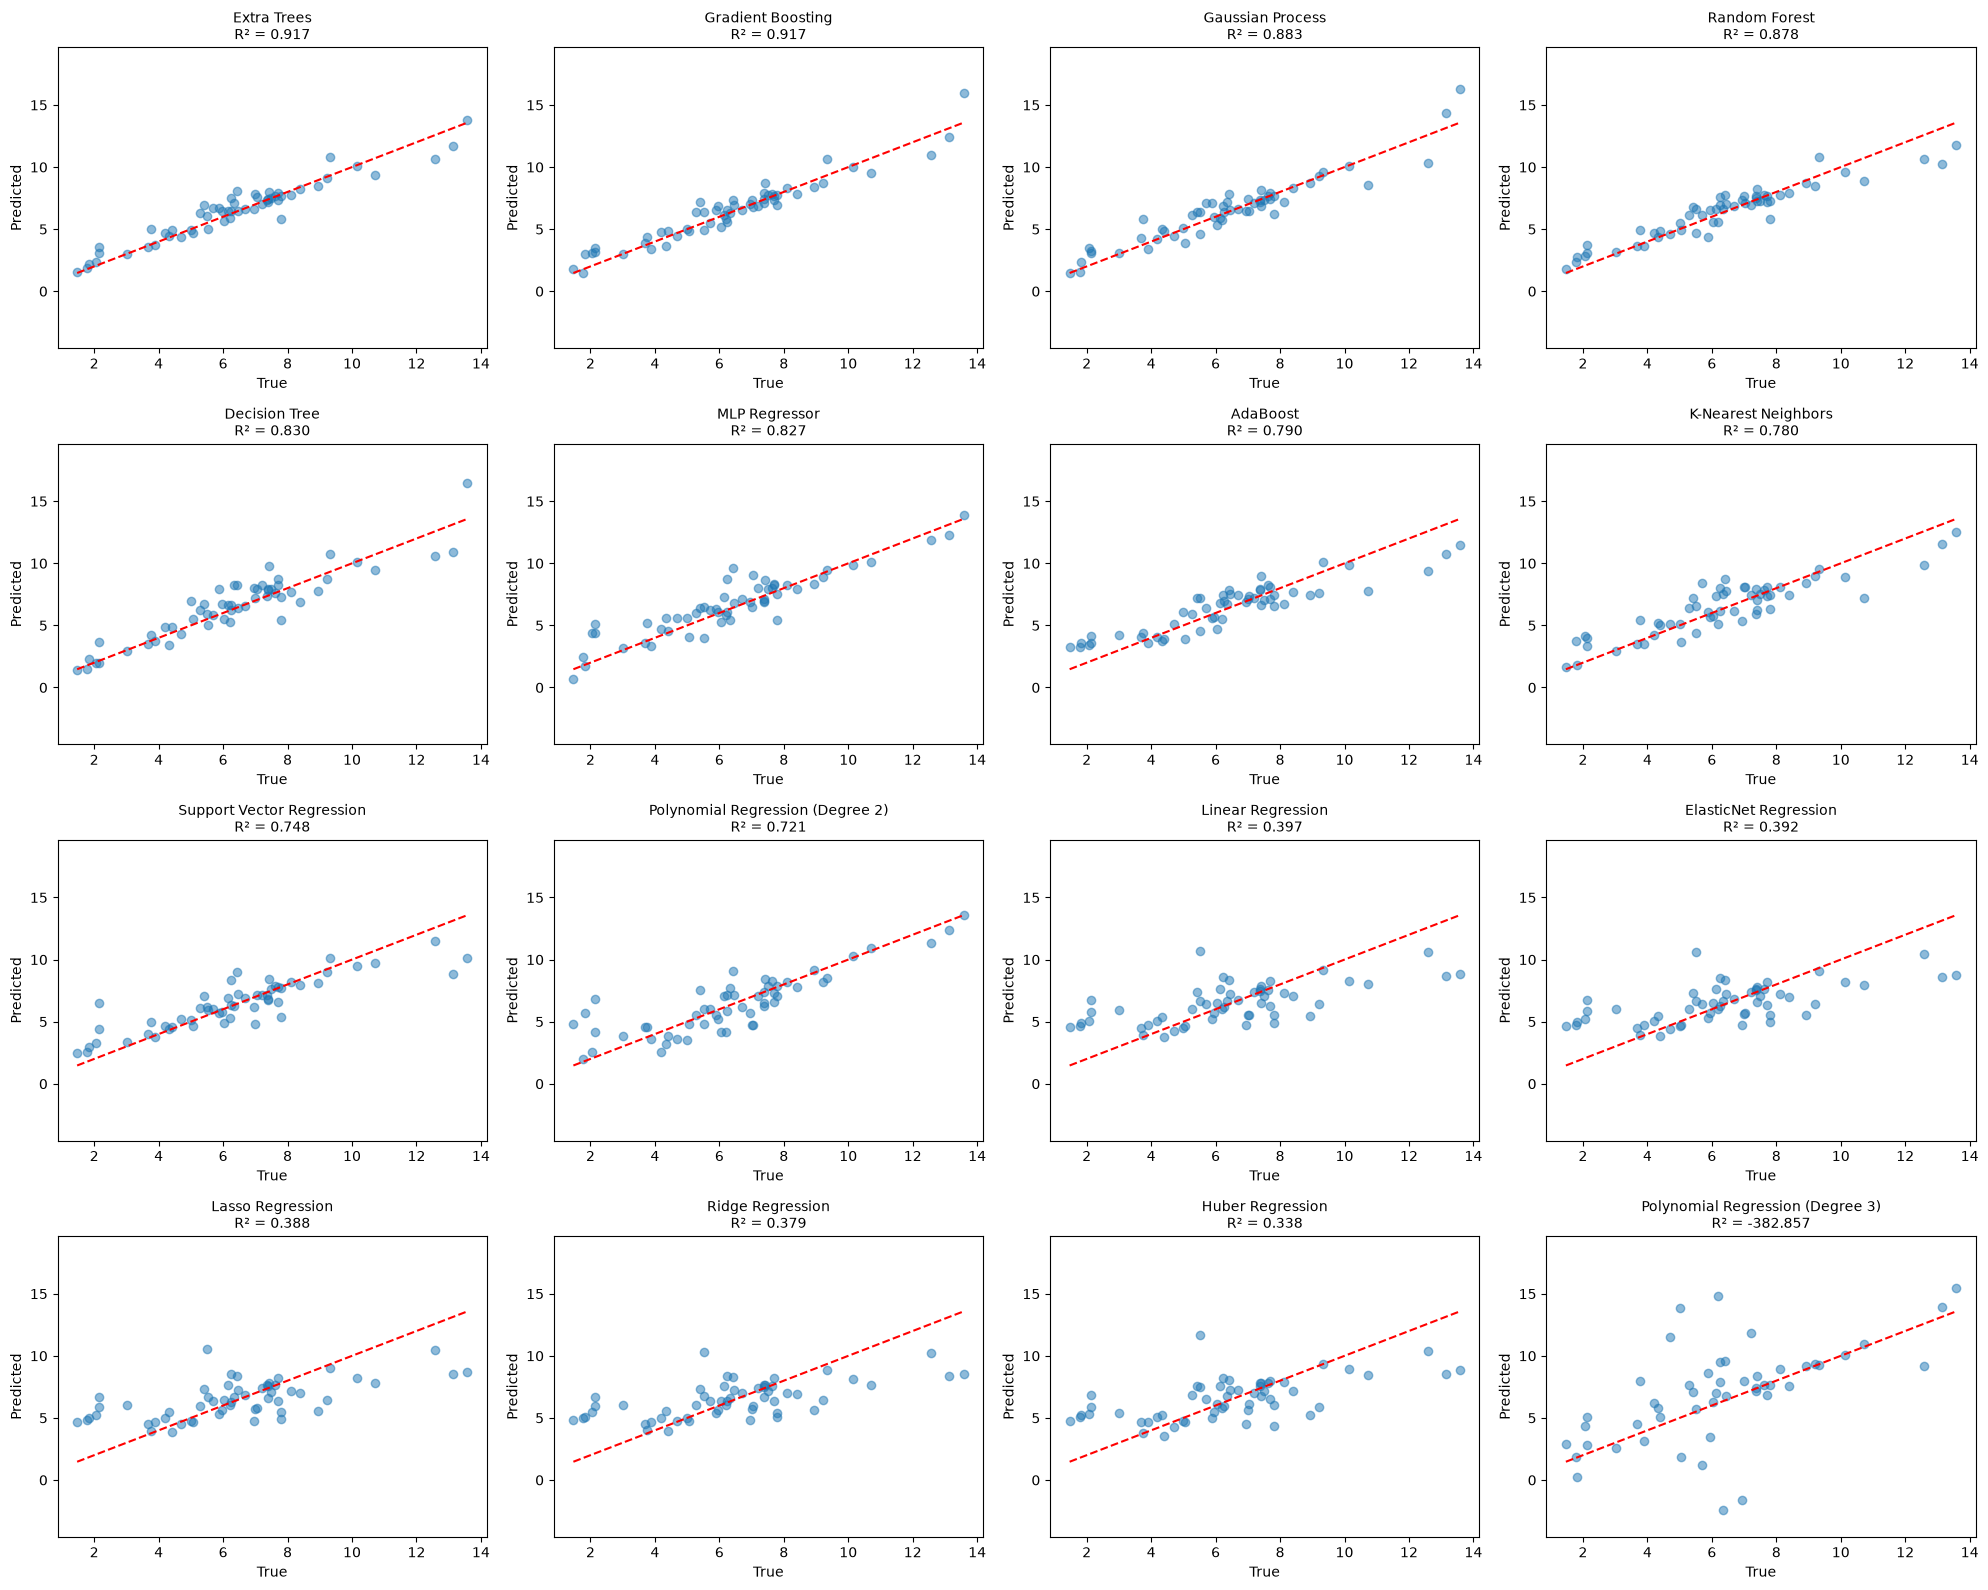

In [8]:
names = results_df['Model'].tolist()
n_cols = 4
n_rows = int(np.ceil(len(names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()
lims = [y_test.min(), y_test.max()]
pad = 0.5 * (lims[1] - lims[0])

for ax, name in zip(axes, names):
    ax.scatter(y_test, predictions[name], alpha=0.5)
    ax.plot(lims, lims, 'r--')
    ax.set_ylim(lims[0] - pad, lims[1] + pad)   # clip wild predictions
    r2 = results_df.loc[results_df['Model'] == name, 'R2 Score'].iloc[0]
    ax.set_title(f'{name}\nR² = {r2:.3f}', fontsize=10)
    ax.set_xlabel('True')
    ax.set_ylabel('Predicted')

for ax in axes[len(names):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()